In [1]:
pip install pandas numpy scikit-learn matplotlib seaborn joblib


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Load dataset (download from: https://www.kaggle.com/datasets/uciml/pima-indiansdiabetes-database)
# OR use sklearn's built-in approach:
url = 'https://gist.githubusercontent.com/tgcsantos/f02a288c38646ad167997c213ae20412/raw/uci_pima_indians_diabetes.csv'


df = pd.read_csv(url)

# ── Basic Exploration ──
print('Shape:', df.shape) # (768, 9)
print(df.head()) # First 5 rows
print(df.info()) # Column types and nulls
print(df.describe()) # Min, max, mean, std for each column
print('Class Distribution:')
print(df['Outcome'].value_counts()) # 500 non-diabetic, 268 diabetic

Shape: (768, 9)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose      

In [11]:
# Columns where 0 is biologically impossible
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
# Replace 0 with NaN
df[zero_cols] = df[zero_cols].replace(0, np.nan)
# Fill NaN with median of each column
df[zero_cols] = df[zero_cols].fillna(df[zero_cols].median())
print('Missing values after fix:', df.isnull().sum().sum()) # Should be 0

Missing values after fix: 0


In [12]:
# X = features (everything except Outcome)
X = df.drop('Outcome', axis=1)
# y = target (what we want to predict)
y = df['Outcome']
print('X shape:', X.shape) # (768, 8)
print('y shape:', y.shape) # (768,)


X shape: (768, 8)
y shape: (768,)


In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
 X, y,
     test_size=0.20, # 20% for testing
 random_state=42, # Seed for reproducibility
 stratify=y # Maintain class ratio in both splits
)
print('Training set size:', X_train.shape) # (614, 8)
print('Test set size: ', X_test.shape) # (154, 8)


Training set size: (614, 8)
Test set size:  (154, 8)


In [16]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# IMPORTANT: Fit ONLY on training data, then transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Use same scaler as training

In [17]:
from sklearn.ensemble import RandomForestClassifier
# Create model with hyperparameters
model = RandomForestClassifier(
 n_estimators=200, # 200 trees in the forest
 max_depth=10, # Limit tree depth to avoid overfitting
 min_samples_split=5, # Minimum samples to split a node
 random_state=42, # Reproducibility
 class_weight='balanced' # Handle class imbalance automatically
)
# TRAIN (fit) the model on training data
model.fit(X_train_scaled, y_train)
print('Training complete!')


Training complete!


Accuracy: 0.7727 (77.3%)
AUC-ROC: 0.8343

Classification Report:
              precision    recall  f1-score   support

Not Diabetic       0.84      0.81      0.82       100
    Diabetic       0.67      0.70      0.68        54

    accuracy                           0.77       154
   macro avg       0.75      0.76      0.75       154
weighted avg       0.78      0.77      0.77       154


Confusion Matrix:
[[81 19]
 [16 38]]


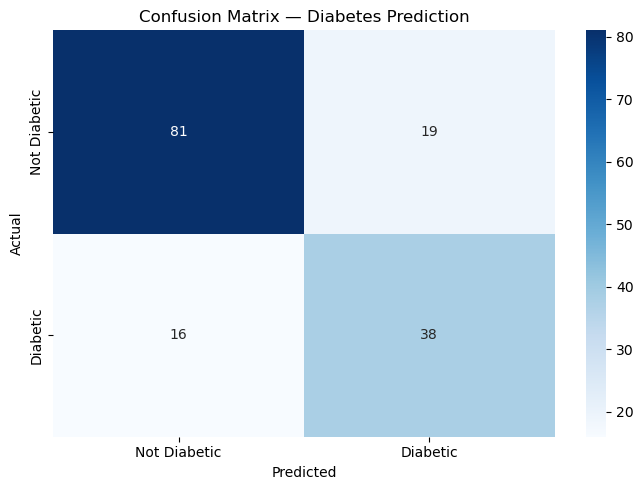

In [18]:
from sklearn.metrics import (classification_report, confusion_matrix,
 accuracy_score, roc_auc_score)
# Make predictions
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1] # Probability of positive class
# ── Accuracy ──
acc = accuracy_score(y_test, y_pred)
print(f'Accuracy: {acc:.4f} ({acc*100:.1f}%)')
# ── AUC-ROC ──
auc = roc_auc_score(y_test, y_prob)
print(f'AUC-ROC: {auc:.4f}')
# ── Full Classification Report ──
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Not Diabetic',
'Diabetic']))
# ── Confusion Matrix ──
cm = confusion_matrix(y_test, y_pred)
print('\nConfusion Matrix:')
print(cm)
# ── Visualize Confusion Matrix ──
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
 xticklabels=['Not Diabetic', 'Diabetic'],
 yticklabels=['Not Diabetic', 'Diabetic'])
plt.title('Confusion Matrix — Diabetes Prediction')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

In [19]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_train_scaled, y_train,
 cv=cv, scoring='f1')
print(f'Cross-Validation F1 Scores: {cv_scores}')
print(f'Mean F1: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')

Cross-Validation F1 Scores: [0.6835443  0.65934066 0.71604938 0.65882353 0.64197531]
Mean F1: 0.6719 +/- 0.0257


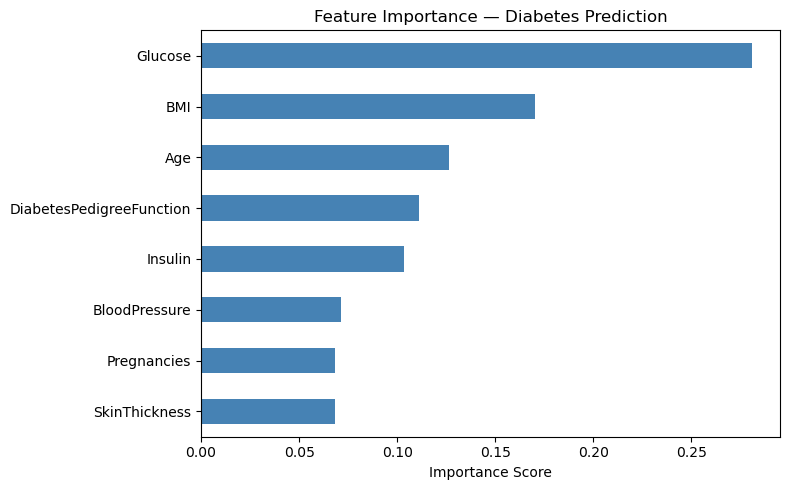

In [20]:
importances = pd.Series(
 model.feature_importances_,
 index=X.columns
)
importances.sort_values().plot(kind='barh', figsize=(8,5), color='steelblue')
plt.title('Feature Importance — Diabetes Prediction')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

In [21]:
import joblib
# Save the trained model
joblib.dump(model, 'diabetes_model.pkl')
# Save the scaler (REQUIRED for new predictions!)
joblib.dump(scaler, 'diabetes_scaler.pkl')
print('Model saved as: diabetes_model.pkl')
print('Scaler saved as: diabetes_scaler.pkl')

Model saved as: diabetes_model.pkl
Scaler saved as: diabetes_scaler.pkl
